### Step 1: Load the Libraies and Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import random
import ordpy 
import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from numpy.linalg import lstsq
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from keras.layers import GRU, LSTM, Dense, Bidirectional, Conv1D, MaxPooling1D, Flatten, Dropout, SimpleRNN
from keras.callbacks import EarlyStopping 

In [2]:
# Set random seed for reproducibility
SEED = 1234
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)  # Ensures hash-based operations remain consistent
os.environ['TF_DETERMINISTIC_OPS'] = '1'  # Forces TensorFlow to use deterministic operations
tf.keras.utils.set_random_seed(SEED)  # Ensures keras layer initialization is consistent
tf.config.experimental.enable_op_determinism()  # Enforce deterministic ops in TensorFlow 2.9+

# Ensure a fresh computation graph
tf.keras.backend.clear_session()

In [3]:
# extracting the data 
data = pd.read_csv(".\datasets\T1.csv")
data.head()

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\aalma\AppData\Local\Temp\ipykernel_44528\1502131984.py:2: SyntaxWarning: invalid escape sequence '\d'
  data = pd.read_csv(".\datasets\T1.csv")


,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286


## Section 1: Data Description

In [4]:
# data decsription (we can see that the data is not normalized) 
data.describe()

,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
count,50530.000000,50530.000000,50530.000000,50530.000000
mean,1307.684332,7.557952,1492.175463,123.687559
std,1312.459242,4.227166,1368.018238,93.443736
min,-2.471405,0.000000,0.000000,0.000000
25%,50.677890,4.201395,161.328167,49.315437
50%,825.838074,7.104594,1063.776283,73.712978
75%,2482.507568,10.300020,2964.972462,201.696720
max,3618.732910,25.206011,3600.000000,359.997589


In [5]:
# data information (Data types, missing values, etc.)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50530 entries, 0 to 50529
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date/Time                      50530 non-null  object 
 1   LV ActivePower (kW)            50530 non-null  float64
 2   Wind Speed (m/s)               50530 non-null  float64
 3   Theoretical_Power_Curve (KWh)  50530 non-null  float64
 4   Wind Direction (°)             50530 non-null  float64
dtypes: float64(4), object(1)
memory usage: 1.9+ MB


In [6]:
data.isnull().sum()

Date/Time                        0
LV ActivePower (kW)              0
Wind Speed (m/s)                 0
Theoretical_Power_Curve (KWh)    0
Wind Direction (°)               0
dtype: int64

In [7]:
# Spliting the date time in year, month, days, hours and minutes
data['Year']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[0])
data['Month']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[1])
data['Day']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[2])
data['Time_Hours']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[3])
data['Time_Minutes']= data['Date/Time'].apply(lambda x: time.strptime(x,"%d %m %Y %H:%M")[4])
data.head(5)

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),Year,Month,Day,Time_Hours,Time_Minutes
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904,2018,1,1,0,0
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113,2018,1,1,0,10
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789,2018,1,1,0,20
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087,2018,1,1,0,30
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286,2018,1,1,0,40


In [8]:
# convert a datetime to a timestamp
data['Date/Time'] = pd.to_datetime(data['Date/Time'], format='%d %m %Y %H:%M')
data


,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),Year,Month,Day,Time_Hours,Time_Minutes
0,2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904,2018,1,1,0,0
1,2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113,2018,1,1,0,10
2,2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789,2018,1,1,0,20
3,2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087,2018,1,1,0,30
4,2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286,2018,1,1,0,40
...,...,...,...,...,...,...,...,...,...,...
50525,2018-12-31 23:10:00,2963.980957,11.404030,3397.190793,80.502724,2018,12,31,23,10
50526,2018-12-31 23:20:00,1684.353027,7.332648,1173.055771,84.062599,2018,12,31,23,20
50527,2018-12-31 23:30:00,2201.106934,8.435358,1788.284755,84.742500,2018,12,31,23,30
50528,2018-12-31 23:40:00,2515.694092,9.421366,2418.382503,84.297913,2018,12,31,23,40


In [9]:
x = [1]  # Convert x to a list
data1 = data.loc[data['Month'].isin(x)]  # selecting the data for the month x
data1 = data1.reset_index(drop=True)  # resetting the index
data1 = data1.dropna()  # dropping the missing values

datas = data1['LV ActivePower (kW)']  # selecting the active power
datas_wind = pd.DataFrame(datas)  # converting to dataframe
dfs = datas  # copying the data
s = dfs.values 


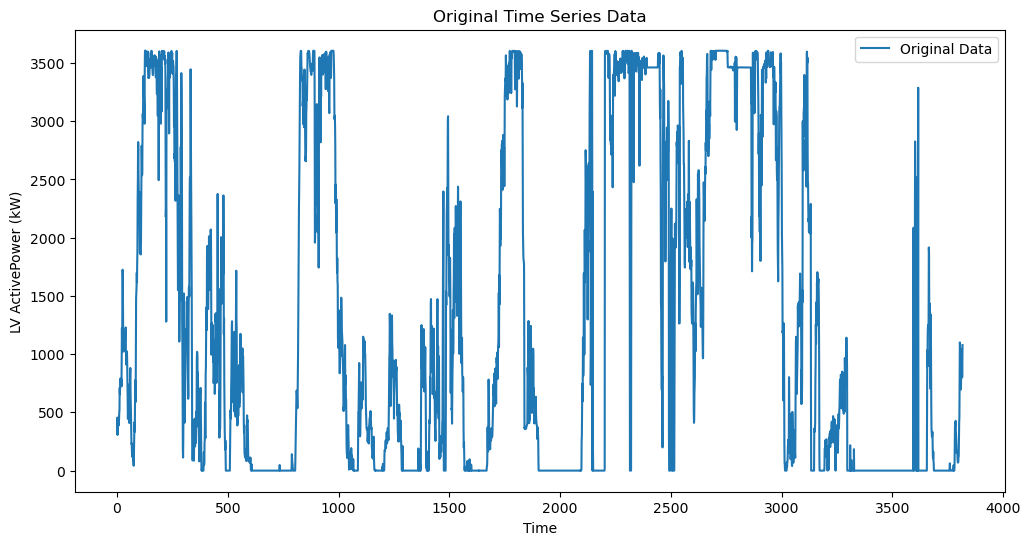

In [10]:
# Plot the original time series data
plt.figure(figsize=(12, 6))
plt.plot(dfs.index, dfs.values, label='Original Data')
plt.title('Original Time Series Data')
plt.xlabel('Time')
plt.ylabel('LV ActivePower (kW)')
plt.legend()
plt.show()

In [11]:
# find the total number of rows
total_rows = datas_wind.count()
total_rows

LV ActivePower (kW)    3817
dtype: int64

In [12]:
s.shape

(3817,)

In [13]:
from PyEMD import EMD,EEMD,CEEMDAN
import ewtpy
# Perform CEEMDAN decomposition
emd = CEEMDAN(epsilon=0.05)
emd.noise_seed(12345)
IMFs = emd(s)
full_imf = pd.DataFrame(IMFs).T
ceemdan1 = full_imf

# Apply EWT on the first IMF
ewt_coeffs, mfb, boundaries = ewtpy.EWT1D(IMFs[0], N=3)
df_ewt = pd.DataFrame(ewt_coeffs)

# Remove the third column if it exists
if df_ewt.shape[1] > 2:
    df_ewt.drop(df_ewt.columns[2], axis=1, inplace=True)

# Sum the EWT components to get the denoised signal
denoised = df_ewt.sum(axis=1, skipna=True)

# Replace first IMF with the denoised version
IMFs[0] = denoised

In [14]:
IMFs

array([[   21.43786435,     7.47314661,    -6.89639925, ...,
          -65.39857897,   -53.42478947,   -26.80973213],
       [    7.22822849,     2.06525928,     2.18106734, ...,
          -97.90983187,  -113.27214896,   -21.64567697],
       [   -9.88525535,    -9.10029839,    -5.96803713, ...,
           56.08386204,    89.28229566,    87.67196176],
       ...,
       [  846.65246234,   847.2443797 ,   847.85292553, ...,
          630.89567151,   629.31896947,   627.719168  ],
       [   44.98509072,    45.27417539,    45.56194199, ...,
        -1902.34011783, -1901.58213097, -1900.81342872],
       [ 1300.97884047,  1301.01556191,  1301.05085637, ...,
         1641.28144552,  1641.20967447,  1641.13841989]])

In [15]:
## Compute Permutation Entropy using ordpy
def permutation_entropy(time_series, order=3):
    return ordpy.permutation_entropy(time_series, dx=order, normalized=True)

# Classify IMFs based on Permutation Entropy
def classify_imfs(imfs, threshold=0.45):
    pe_values = [permutation_entropy(imf) for imf in imfs]
    high_freq_imfs, low_freq_imfs = [], []
    
    for i, pe in enumerate(pe_values):
        if pe > threshold:
            high_freq_imfs.append(imfs[i])
        else:
            low_freq_imfs.append(imfs[i])
    
    return high_freq_imfs, low_freq_imfs, pe_values

high_freq, low_freq, pe_values = classify_imfs(IMFs)

In [16]:
len(high_freq), len(low_freq)

(5, 5)

In [17]:
high_freq

[array([ 21.43786435,   7.47314661,  -6.89639925, ..., -65.39857897,
        -53.42478947, -26.80973213]),
 array([   7.22822849,    2.06525928,    2.18106734, ...,  -97.90983187,
        -113.27214896,  -21.64567697]),
 array([-9.88525535, -9.10029839, -5.96803713, ..., 56.08386204,
        89.28229566, 87.67196176]),
 array([-144.57084303, -147.06024134, -146.18697913, ...,  109.73102134,
          98.67275341,   95.42918708]),
 array([-395.96464395, -395.77061941, -393.5937689 , ...,  170.55681181,
         163.5510627 ,  152.72569414])]

In [18]:
low_freq

[array([292.89692205, 299.08439746, 304.22769482, ..., 403.205271  ,
        403.45212108, 402.72331324]),
 array([-1552.20259003, -1563.66299988, -1574.6314223 , ...,
         -108.80469948,  -104.73940611,  -100.69144456]),
 array([846.65246234, 847.2443797 , 847.85292553, ..., 630.89567151,
        629.31896947, 627.719168  ]),
 array([   44.98509072,    45.27417539,    45.56194199, ...,
        -1902.34011783, -1901.58213097, -1900.81342872]),
 array([1300.97884047, 1301.01556191, 1301.05085637, ..., 1641.28144552,
        1641.20967447, 1641.13841989])]

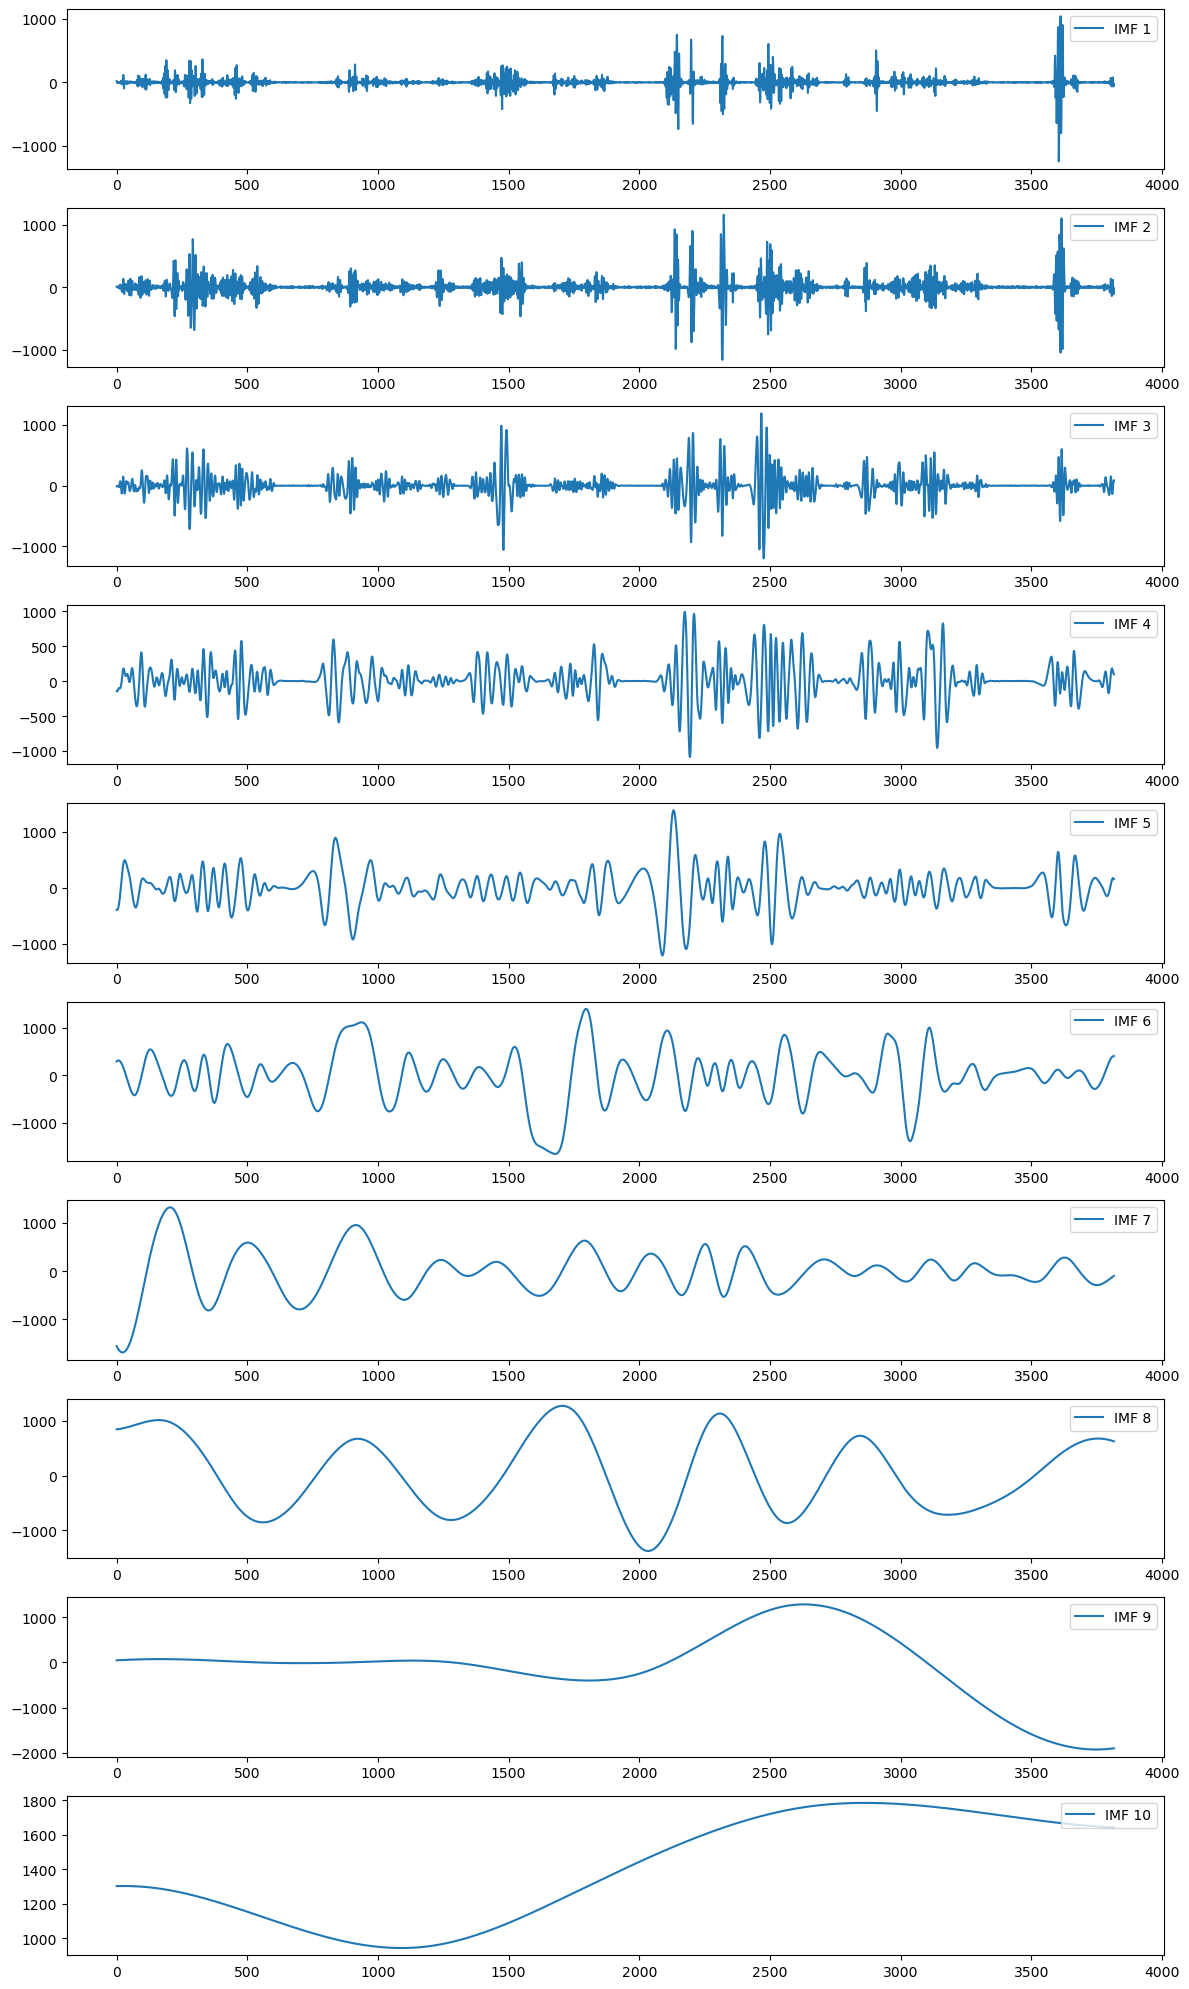

In [19]:
# Plot the CEEMDAN IMFs and the denoised signal
num_imfs = IMFs.shape[0]
plt.figure(figsize=(12, 2 * num_imfs))
for idx in range(num_imfs):
    plt.subplot(num_imfs, 1, idx + 1)
    plt.plot(ceemdan1.iloc[:, idx], label=f'IMF {idx + 1}')
    plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

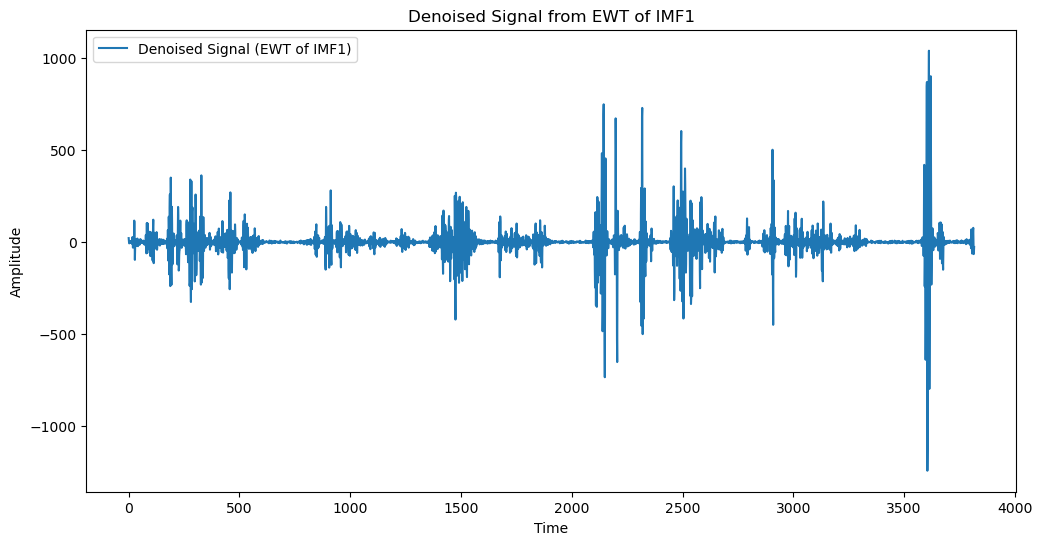

In [20]:
# Plot the denoised signal
plt.figure(figsize=(12, 6))
plt.plot(denoised, label='Denoised Signal (EWT of IMF1)')
plt.title('Denoised Signal from EWT of IMF1')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.show()


In [21]:
def create_xy(data, input_length, output_length):
    """
    Generates input (x) and output (y) pairs from time series data based on the specified input and output lengths.

    Parameters:
    - data (np.ndarray or list): The time series data as a numpy array or list.
    - input_length (int): The number of time steps for the input sequence.
    - output_length (int): The number of time steps for the output sequence.

    Returns:
    - x (np.ndarray): The array of input sequences with shape (num_samples, input_length).
    - y (np.ndarray): The array of output sequences with shape (num_samples, output_length).
    """
    x, y = [], []
    total_length = len(data)

    # Iterate over the dataset to create input-output pairs
    for i in range(total_length - input_length - output_length + 1):
        x.append(data[i:i + input_length])
        y.append(data[i + input_length:i + input_length + output_length])
    
    return np.array(x), np.array(y)

## Step 3: Buidling the EMD with LSTM

In [22]:
# Model training
def train_model(X_train, y_train, X_test, y_test, model_type='GRU', neuron=128, epochs=30, batch_size=64, lr=0.001):
    model = Sequential()
    
    if model_type == 'GRU':
        model.add(GRU(units=neuron, input_shape=(X_train.shape[1], X_train.shape[2])))
    elif model_type == 'BiLSTM':
        model.add(Bidirectional(LSTM(units=neuron, input_shape=(X_train.shape[1], X_train.shape[2]))))
    
    model.add(Dense(1))
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(loss='mse', optimizer=optimizer)
    
    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, verbose=0)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    return y_pred_train, y_pred_test

In [23]:
# Training loop
pred_test, test_ori, pred_train, train_ori = [], [], [], []
input_length, output_length = 6, 1
data_partition = 0.8

In [24]:
for dataset, model_type in zip([high_freq, low_freq], ['GRU', 'BiLSTM']):
    for component in dataset:
        dataset_col = np.array(component).reshape(-1, 1)
        train_size = int(len(dataset_col) * data_partition)
        train, test = dataset_col[:train_size], dataset_col[train_size:]
        X_train, y_train = create_xy(train, input_length, output_length)
        X_test, y_test = create_xy(test, input_length, output_length)
        
        if len(X_train) == 0 or len(X_test) == 0:
            continue
        
        # Reshape input
        X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
        X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
        
        # Standardize data
        sc_X, sc_y = StandardScaler(), StandardScaler()
        X_train, y_train = sc_X.fit_transform(X_train.reshape(X_train.shape[0], -1)), sc_y.fit_transform(y_train.reshape(-1, 1)).ravel()
        X_test, y_test = sc_X.transform(X_test.reshape(X_test.shape[0], -1)), sc_y.transform(y_test.reshape(-1, 1)).ravel()
        
        # Reshape for LSTM/GRU
        X_train = X_train.reshape(X_train.shape[0], input_length, 1)
        X_test = X_test.reshape(X_test.shape[0], input_length, 1)
        
        # Train model
        y_pred_train, y_pred_test = train_model(X_train, y_train, X_test, y_test, model_type=model_type)
        
        # Inverse transform
        y_pred_train_inv = sc_y.inverse_transform(y_pred_train)
        y_pred_test_inv = sc_y.inverse_transform(y_pred_test)
        y_train_inv = sc_y.inverse_transform(y_train.reshape(-1, 1))
        y_test_inv = sc_y.inverse_transform(y_test.reshape(-1, 1))
        
        # Store results
        pred_train.append(y_pred_train_inv.flatten())
        pred_test.append(y_pred_test_inv.flatten())
        train_ori.append(y_train_inv.flatten())
        test_ori.append(y_test_inv.flatten())


c:\Users\aalma\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


c:\Users\aalma\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


c:\Users\aalma\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


c:\Users\aalma\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


c:\Users\aalma\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [25]:
# Convert lists to DataFrames
result_pred_test = pd.DataFrame(pred_test).T  # Transpose to align with actual values
result_pred_train = pd.DataFrame(pred_train).T


# Sum predictions across components
a = result_pred_test.sum(axis=1)
b = result_pred_train.sum(axis=1)



In [26]:
# Prepare actual data
dataset = dfs.values.reshape(-1, 1)
train_size = int(len(dataset) * data_partition)
train, test = dataset[:train_size], dataset[train_size:]

# Create datasets for training and testing
_, trainY = create_xy(train, input_length, output_length)
_, testY = create_xy(test, input_length, output_length)

# Scale the data
sc_y_total = StandardScaler()
y_train_scaled = sc_y_total.fit_transform(trainY.reshape(-1, 1))
y_test_scaled = sc_y_total.transform(testY.reshape(-1, 1))

# Inverse transform actual values
y_test_inv = sc_y_total.inverse_transform(y_test_scaled).flatten()
y_train_inv = sc_y_total.inverse_transform(y_train_scaled).flatten()


In [27]:
# Ensure the lengths match
min_length = min(len(a), len(y_test_inv))
a = a[:min_length]
y_test_series = y_test_inv[:min_length]

# Calculate error metrics
rmse = np.sqrt(mean_squared_error(y_test_series, a))
mae = mean_absolute_error(y_test_series, a)
r2 = r2_score(y_test_series, a)

# Print the results
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R2: {r2:.3f}")


RMSE: 128.312
MAE: 73.786
R2: 0.967


In [28]:
### Calculate margin of error
 
# Example error array
errors = y_test_series - a
errors = np.array(errors)
 
# Calculate standard deviation
std_dev = np.std(errors)
 
# Number of observations
n = len(errors)
 
# Z-score for 95% confidence
z_score = 1.96
 
# Calculate margin of error
margin_of_error = z_score * (std_dev / np.sqrt(n))
 
print(f"Margin of Error: {margin_of_error:.3f}")

Margin of Error: 8.762


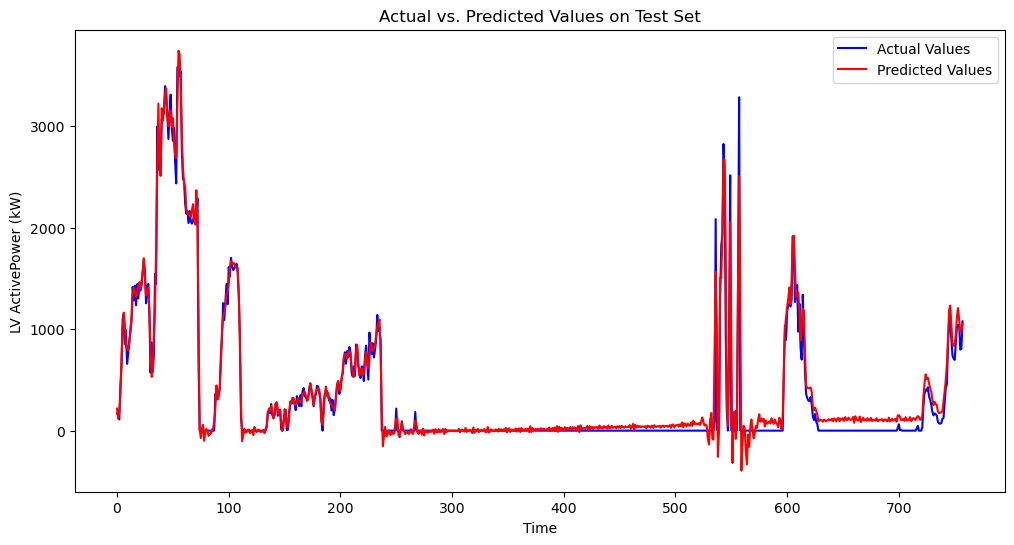

In [29]:
plt.figure(figsize=(12, 6))
plt.plot(y_test_series, label='Actual Values', color='blue')
plt.plot(a.values, label='Predicted Values', color='red')
plt.title('Actual vs. Predicted Values on Test Set')
plt.xlabel('Time')
plt.ylabel('LV ActivePower (kW)')
plt.legend()
plt.show()


In [30]:
aggregated_signal = result_pred_test.sum(axis=1)

In [31]:
# remove any negative values for aggregated signal
aggregated_signal[aggregated_signal < 0] = 0

In [32]:
# Ensure the lengths match
min_length = min(len(aggregated_signal), len(y_test_inv))
aggregated_signal = aggregated_signal[:min_length]
y_test_series = y_test_inv[:min_length]

# Calculate error metrics
rmse = np.sqrt(mean_squared_error(y_test_series, aggregated_signal))
mae = mean_absolute_error(y_test_series, aggregated_signal)
r2 = r2_score(y_test_series, aggregated_signal)

# Print the results
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")
print(f"R2: {r2:.3f}")

RMSE: 124.659
MAE: 67.860
R2: 0.969


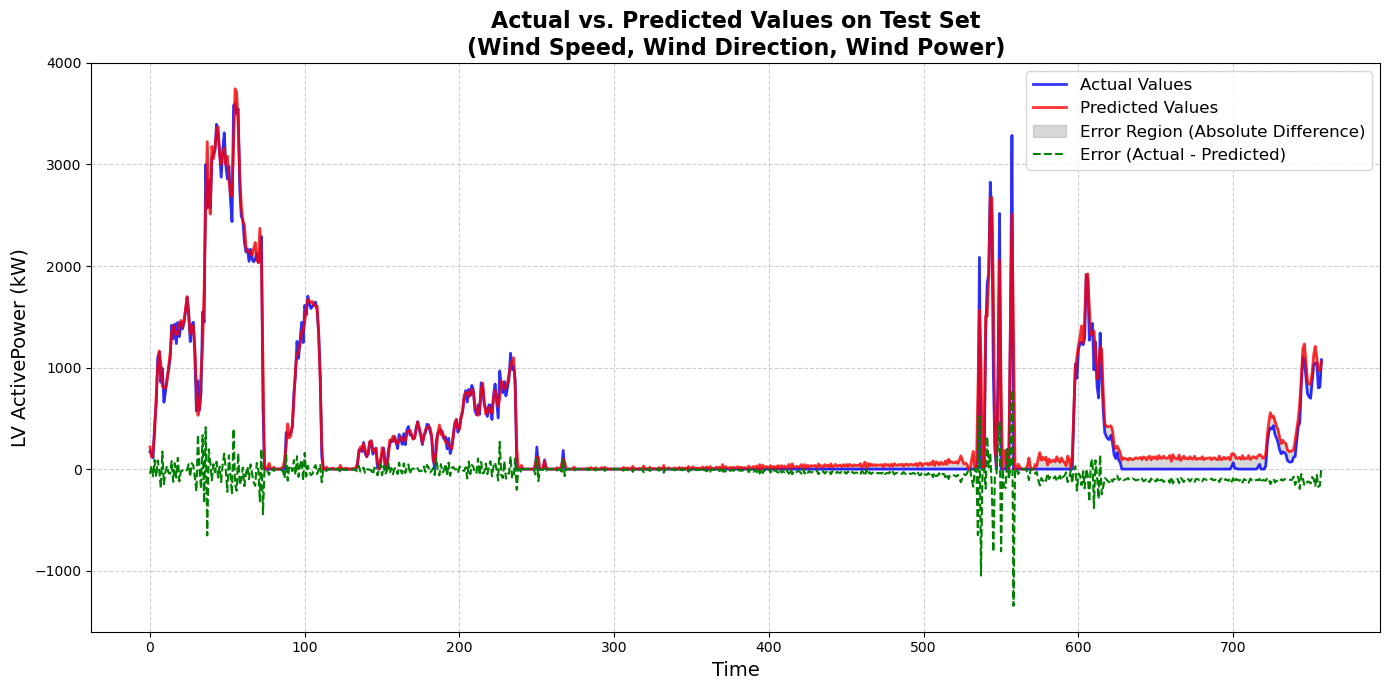

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the error
error = y_test_series - aggregated_signal

plt.figure(figsize=(14, 7))

# Plot actual values
plt.plot(
    y_test_series, 
    label='Actual Values', 
    color='blue', 
    linewidth=2, 
    alpha=0.8
)

# Plot predicted values
plt.plot(
    aggregated_signal, 
    label='Predicted Values', 
    color='red', 
    linewidth=2, 
    alpha=0.8
)

# Highlight the error region
plt.fill_between(
    range(len(y_test_series)), 
    y_test_series, 
    aggregated_signal, 
    color='gray', 
    alpha=0.3, 
    label='Error Region (Absolute Difference)'
)

# Plot error line
plt.plot(
    error, 
    label='Error (Actual - Predicted)', 
    color='green', 
    linestyle='--', 
    linewidth=1.5
)

# Add grid, labels, and legend
plt.title(
    'Actual vs. Predicted Values on Test Set\n(Wind Speed, Wind Direction, Wind Power)', 
    fontsize=16, 
    fontweight='bold'
)
plt.xlabel('Time', fontsize=14)
plt.ylabel('LV ActivePower (kW)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(visible=True, linestyle='--', alpha=0.6)

# Display the plot
plt.tight_layout()
plt.show()
